In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx

import numpy as np

import sys
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/final/training")

import matplotlib.pyplot as plt
from helpers import adjust_plot_1d, get_bin_idx, load_table_from_pickle

import matplotlib.pyplot as plt
from scipy.special import softmax
import copy

from collections import defaultdict


2026-06-01 12:03:55.831947: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def pdf(x, a, b):
    y = a*b*(1. - np.exp(-b*x))**(a-1) * np.exp(-b*x)
    return jnp.where(x > 0, y, 0)

def pdf_mixed(x, a, b, mix_probs):
    x = jnp.expand_dims(x, axis=0)
    a = jnp.expand_dims(a, axis=-1)
    b = jnp.expand_dims(b, axis=-1)
    mix_probs = jnp.expand_dims(mix_probs, axis=-1)
    return jnp.sum(mix_probs * pdf(x, a, b), axis=0)


In [3]:
plot_args = defaultdict(list)

rho = 0.0
depths = [500, 210, -210, -500]

# up to 16m
scale1 = 5
scale2 = 10
scale3 = 50
dists = [3.0, 4.0, 5.3, 6.5, 8, 13]
for dist in dists:
    for z in depths:
        plot_args['plot_dist'].append(dist)
        plot_args['plot_z'].append(z)
        plot_args['plot_rho'].append(rho)
        plot_args['scale1'].append(scale1)
        plot_args['scale2'].append(scale2)
        plot_args['scale3'].append(scale3)

# up to 60m
scale1 = 10
scale2 = 20
scale3 = 50
dists = [16.0, 20.0, 25.0, 35.0, 42.0, 50.0]
for dist in dists:
    for z in depths:
        plot_args['plot_dist'].append(dist)
        plot_args['plot_z'].append(z)
        plot_args['plot_rho'].append(rho)
        plot_args['scale1'].append(scale1)
        plot_args['scale2'].append(scale2)
        plot_args['scale3'].append(scale3)

# up to 150m
scale1 = 20
scale2 = 40
scale3 = 50
dists = [60.0, 75.0, 100.0]
for dist in dists:
    for z in depths:
        plot_args['plot_dist'].append(dist)
        plot_args['plot_z'].append(z)
        plot_args['plot_rho'].append(rho)
        plot_args['scale1'].append(scale1)
        plot_args['scale2'].append(scale2)
        plot_args['scale3'].append(scale3)
#scale1, scale2, scale3 = 30, 50, 50
# up to 400m
scale1 = 30
scale2 = 50
scale3 = 50
dists = [150.0, 200.0, 250.0, 300.0, 400.0]
for dist in dists:
    for z in depths:
        plot_args['plot_dist'].append(dist)
        plot_args['plot_z'].append(z)
        plot_args['plot_rho'].append(rho)
        plot_args['scale1'].append(scale1)
        plot_args['scale2'].append(scale2)
        plot_args['scale3'].append(scale3)


In [4]:
class TriplePandelNet(eqx.Module):
    layer0: eqx.Module
    layer1: eqx.Module
    layer2: eqx.Module
    layer3: eqx.Module
    layer4: eqx.Module
    layer5: eqx.Module
    layer6: eqx.Module

    def __init__(self, key, hidden_size=96):
        key = jax.random.split(key, 7)
        self.layer0 = eqx.nn.Linear(7, hidden_size, key=key[0, :])
        self.layer1 = eqx.nn.Linear(hidden_size, hidden_size, key=key[1, :])
        self.layer2 = eqx.nn.Linear(hidden_size, hidden_size, key=key[2, :])
        self.layer3 = eqx.nn.Linear(hidden_size, hidden_size, key=key[3, :])
        self.layer4 = eqx.nn.Linear(hidden_size, hidden_size, key=key[4, :])
        self.layer5 = eqx.nn.Linear(hidden_size, hidden_size, key=key[5, :])
        self.layer6 = eqx.nn.Linear(hidden_size+1, 12, key=key[6, :])

    def eval(self, x):
        d = x[0:1]

        x = jnp.tanh(self.layer0(x))
        x = jnp.tanh(self.layer1(x)) + x
        x = jnp.tanh(self.layer2(x)) + x
        x = jnp.tanh(self.layer3(x)) + x
        x = jnp.tanh(self.layer4(x)) + x
        x = jnp.tanh(self.layer5(x)) + x

        # outputs
        y = self.layer6(jnp.concatenate([x, d], axis=-1))

        # try to put an ordering on the components
        # by shifting initialization
        to_be_b = y[8:] + jnp.array([-7.62061505, -6.69140313, -5.70345812, -3.89233063])

        x = jnp.concatenate([y[:8], to_be_b], axis=-1)
        return x

    def __call__(self, x):
        return self.eval(x)

    def transform_output_logits(self, y):
        eps = 1.e-20
        # Stable positive transform
        a = 1.0 + jax.nn.softplus(y[4:8]) + eps
        # a = 1.0 + jnp.exp(y[4:8]) + eps
        # a = jnp.clip(1.0 + jax.nn.softplus(y[4:8]), 1.0, 10.0)
        # gamma_b safe
        b = 1.0 / (1.e4*jax.nn.sigmoid(y[8:12]) + 0.1)
        # b = 0.01 + jax.nn.softplus(y[8:12])
        return jnp.concatenate([y[0:4], a, b])


    def transform_output_probs(self, y):
        eps = jnp.array(1.e-20)
        # get a and b
        y2 = self.transform_output_logits(y)
        # compute weights from logits
        weights = jax.nn.softmax(y[:4])
        # combine
        return jnp.concatenate([weights, y2[4:]])


    def transform_input(self, x):
        # x = [dist, rho, z, zenith, azimuth]
        # distance/z units: m
        # angle units: rad

        km_scale = 1000.
        d = x[0] / km_scale
        rho_x = jnp.cos(x[1])
        rho_y = jnp.sin(x[1])
        z = x[2] / km_scale

        sin_zen = jnp.sin(x[3])
        dir_z = jnp.cos(x[3])

        dir_x = sin_zen * jnp.cos(x[4])
        dir_y = sin_zen * jnp.sin(x[4])

        return jnp.array([d, rho_x, rho_y, z, dir_z, dir_x, dir_y])

    def eval_from_training_input(self, x):
        # x = [dist, rho_x, rho_y, z, dir_z, dir_x, dir_y]
        # distance in units of km
        # rho, dir as cartesian unit vector components

        y = self.eval(x)

        # during training we want predictions to be on logit scale
        return self.transform_output_logits(y)

    def eval_from_cylindrical_reco_input(self, x):
        # x = [dist, rho, z, zenith, azimuth]
        # distance/z units: m
        # angle units: rad

        x = self.transform_input(x)
        y = self.eval(x)

        # this function is used for penalities.
        # we want the second derivatives to be penalized
        # on the probability scale (not logit).
        return self.transform_output_probs(y)

    def cartesian2cylindrical(self, x):
         # x = [dist, rho_x, rho_y, z, dir_z, dir_x, dir_y]
         rho = jnp.atan2(x[2], x[1])
         zenith = jnp.arccos(x[4])
         azimuth = jnp.atan2(x[6], x[5])
         return jnp.array([x[0], rho, x[3], zenith, azimuth])

    def smoothness_penalty_wrt_cylindrical_reco_input(self, x, penalties):
        # penalties : matrix of shape = (9, 5) =  (network_outputs, network_inputs)
        hessian_diag = jnp.diagonal(
                                        jax.jacfwd(jax.jacfwd(self.eval_from_cylindrical_reco_input))(x),
                                        axis1=1, axis2=2
                                    )
        return jnp.sum(penalties * hessian_diag * hessian_diag)


In [5]:
zenith = 23.556464309101234
azimuth = 67.5
zenith = 23.556464309101234
azimuth = 67.5
infile = f'/mnt/research/IceCube/Gupta-Reco/photon_tables_pkl/phototable_infinitemuon_zenith{zenith}_azimuth{azimuth}.pkl'
table, bin_info = load_table_from_pickle(infile)

In [26]:

jax.config.update("jax_enable_x64", False)
model_serialization_path = '/mnt/scratch/baburish/TPN-training/final/TPN_God/data/4comp_no_penalties_w4096batch_tree_start_epoch_255.eqx'
key = jax.random.PRNGKey(0)
model = TriplePandelNet(key)
model = eqx.tree_deserialise_leaves(model_serialization_path, model)
model_eval = eqx.filter_jit(model.eval_from_cylindrical_reco_input)

In [27]:
def make_dt_plot_w_pdf(dist, rho, z, zenith, azimuth, model, table, bin_info, scale=10, logscale=False,  outfile="tmp.png"):

    y = model_eval(jnp.array([dist, rho, z, np.deg2rad(zenith), np.deg2rad(azimuth)], dtype=jnp.float64))
    weights, gamma_a, gamma_b = y[:4], y[4:8], y[8:]

    i = get_bin_idx(dist, bin_info['dist']['e'])
    j = get_bin_idx(rho, bin_info['rho']['e'])
    k = get_bin_idx(z, bin_info['z']['e'])

    prob_vals = copy.copy(table['values'][i, j, k, :])
    prob_err = copy.copy(np.sqrt(table['weights'][i, j, k, :]))

    tot_prob = np.sum(prob_vals)
    if tot_prob == 0:
        return

    prob_vals /= tot_prob
    prob_vals /= bin_info['dt']['w']

    prob_err /= tot_prob
    prob_err /= bin_info['dt']['w']

    fig, ax = plt.subplots()
    ax.hist(bin_info['dt']['c'], bins=bin_info['dt']['e'], weights=prob_vals, histtype='step', lw=1,
            label=f"(d={dist:.1f}m, $\\rho$ ={rho:.2f} rad, z={z:.0f}m)", color='gray')
    ax.errorbar(bin_info['dt']['c'], prob_vals, yerr = prob_err, lw=0, elinewidth=2,color='k', zorder=100)

    xvals = np.linspace(-50, scale*dist, 1000)
    xv = jnp.array(xvals, dtype=jnp.float64)
    w = weights

    yvals = np.asarray(pdf_mixed(xv, gamma_a, gamma_b, w))
    plt.plot(xvals, yvals, 'r-', zorder=10, linewidth=2, label='4-comp Gupta')

    plot_args = {'xlim':[-2, scale*dist],
                 'ylim':[0.0, 1.2 * np.amax([np.amax(prob_vals), np.amax(yvals)])],
                 'xlabel':'dt [ns]',
                 'ylabel':'pdf'}

    for i,c in zip(range(4), ['purple', 'plum', 'pink', 'cornflowerblue']):
        tw = w[i]
        yvals = np.asarray(tw * pdf(xv, gamma_a[i], gamma_b[i]))
        plt.plot(xvals, yvals, color=c,linestyle='solid', zorder=8, linewidth=1.5,
                label=f'Gupta Mode {i}')

    adjust_plot_1d(fig, ax, plot_args=plot_args)

    ax.set_title(f"infinite $\mu$ ($\Theta_s$={zenith:.0f}deg, $\Phi_s$={azimuth:.0f}deg)")
    # plt.xlim(xmax=10)
    # if logscale:
    # plt.yscale('log')
    plt.ylim(ymin=1.e-5)
    plt.xlim(0,10)
    plt.tight_layout()
    # plt.savefig(outfile, dpi=300)


def get_nearest_center_value(dist, z, rho):
    i = get_bin_idx(dist, bin_info['dist']['c'])
    j = get_bin_idx(z, bin_info['z']['c'])
    k = get_bin_idx(rho, bin_info['rho']['c'])

    return bin_info['dist']['c'][i], bin_info['z']['c'][j], bin_info['rho']['c'][k]

2.8732402408529927 490.0 -0.0872664625997166
generating plot: 2.8732402408529927 490.0 -0.0872664625997166
2.8732402408529927 210.0 -0.0872664625997166
generating plot: 2.8732402408529927 210.0 -0.0872664625997166
2.8732402408529927 -210.0 -0.0872664625997166
generating plot: 2.8732402408529927 -210.0 -0.0872664625997166
2.8732402408529927 -510.0 -0.0872664625997166
generating plot: 2.8732402408529927 -510.0 -0.0872664625997166


/tmp/ipykernel_3219349/2431261978.py:3: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  y = model_eval(jnp.array([dist, rho, z, np.deg2rad(zenith), np.deg2rad(azimuth)], dtype=jnp.float64))
/tmp/ipykernel_3219349/2431261978.py:29: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  xv = jnp.array(xvals, dtype=jnp.float64)
/tmp/ipykernel_3219349/3337231864.py:2: RuntimeWarning: overflow encountered in exp
  y = a*b*(1. - np.exp(-b*x))**(a-1) * np.ex

3.6426628166904544 490.0 -0.0872664625997166
generating plot: 3.6426628166904544 490.0 -0.0872664625997166
3.6426628166904544 210.0 -0.0872664625997166
generating plot: 3.6426628166904544 210.0 -0.0872664625997166
3.6426628166904544 -210.0 -0.0872664625997166
generating plot: 3.6426628166904544 -210.0 -0.0872664625997166
3.6426628166904544 -510.0 -0.0872664625997166
generating plot: 3.6426628166904544 -510.0 -0.0872664625997166
4.967901170615397 490.0 -0.0872664625997166
generating plot: 4.967901170615397 490.0 -0.0872664625997166
4.967901170615397 210.0 -0.0872664625997166
generating plot: 4.967901170615397 210.0 -0.0872664625997166


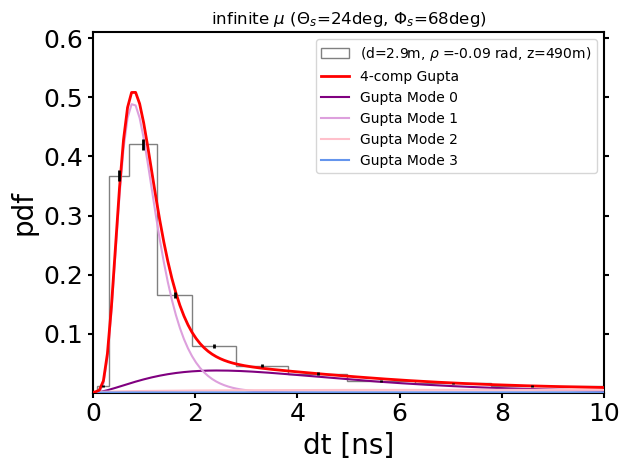

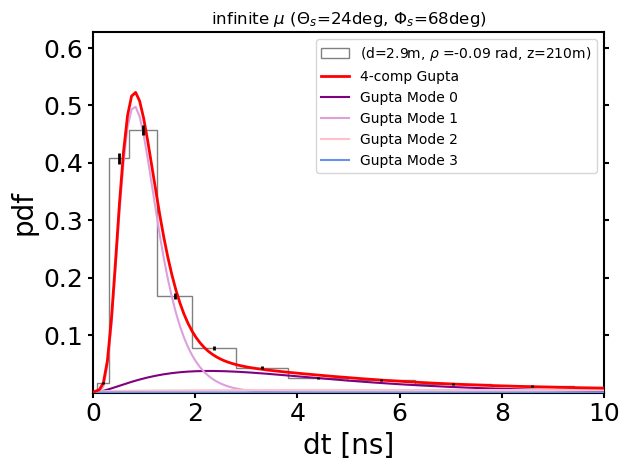

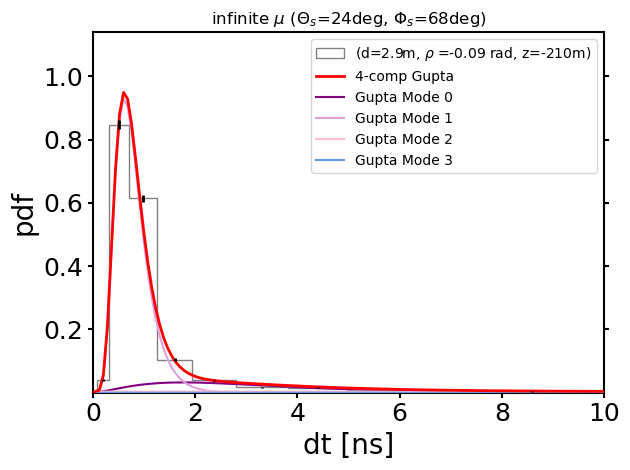

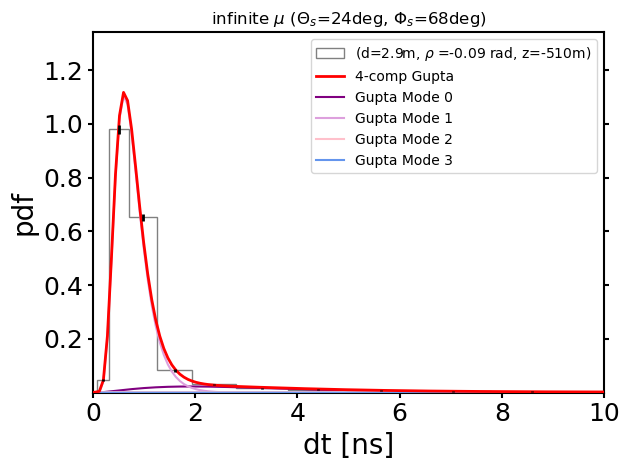

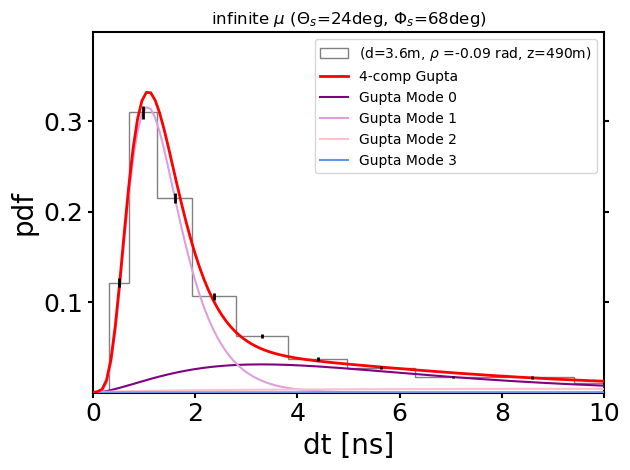

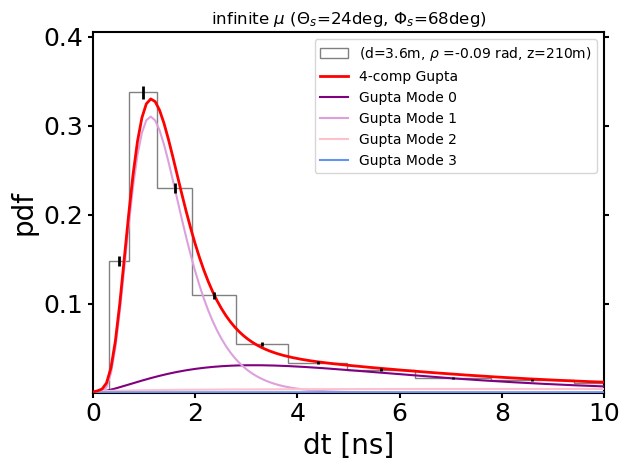

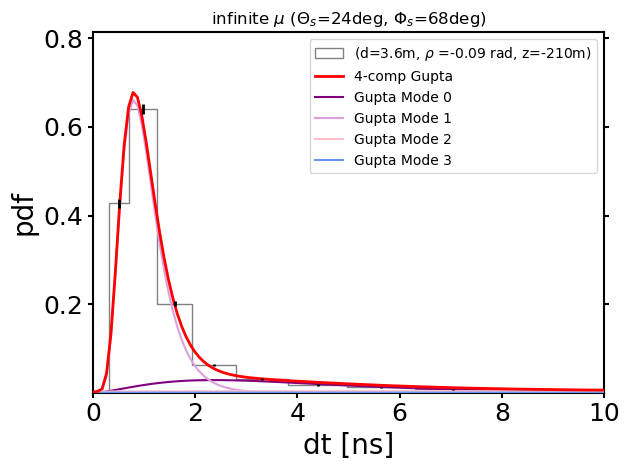

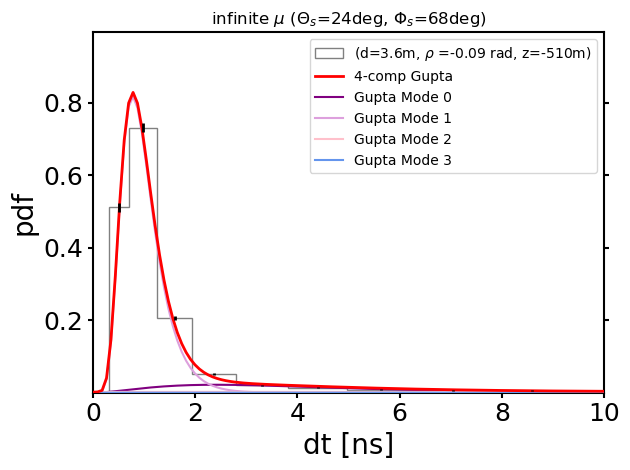

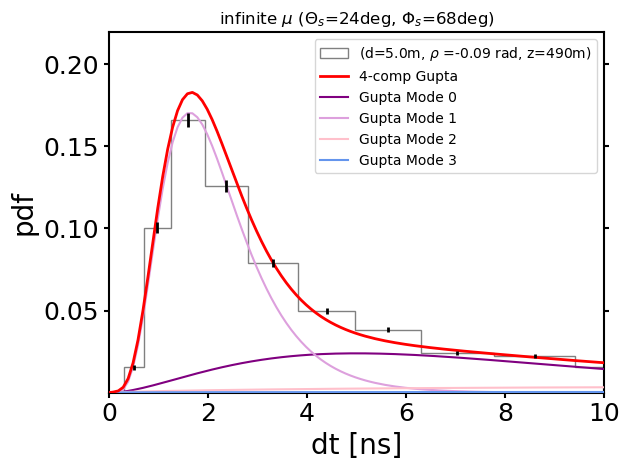

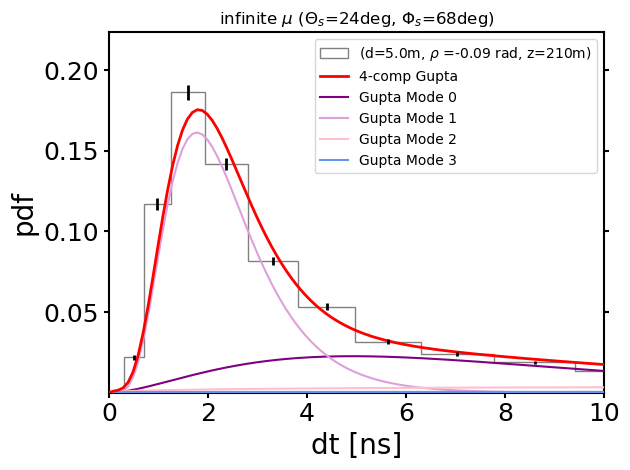

In [28]:
# for i in range(len(plot_args['plot_dist'])):
for i in range(0, 10):
    plot_dist, plot_rho, plot_z = plot_args['plot_dist'][i], plot_args['plot_rho'][i], plot_args['plot_z'][i]
    scale1, scale2, scale3 = plot_args['scale1'][i], plot_args['scale2'][i], plot_args['scale3'][i]


    dist, z, rho = get_nearest_center_value(plot_dist, plot_z, plot_rho)
    print(    dist, z, rho)
    print("generating plot:", dist, z, rho)
    outfile=f'oldlinear_dist_{dist:04.1f}m_z_{z:.1f}m_rho_{rho:.1f}_scale_{scale1}.png'
    make_dt_plot_w_pdf(dist, rho, z, zenith, azimuth, model, table, bin_info, scale=scale2, outfile=outfile)
    # outfile=f'./png_tmp/linear_dist_{dist:04.1f}m_z_{z:.1f}m_rho_{rho:.1f}_scale_{scale2}.png'
    # make_dt_plot_w_pdf(dist, rho, z, zenith, azimuth, model, table, bin_info, scale=scale2, outfile=outfile)
    # outfile=f'./png_tmp/log_dist_{dist:04.1f}m_z_{z:.1f}m_rho_{rho:.1f}_scale_{scale3}.png'
    # make_dt_plot_w_pdf(dist, rho, z, zenith, azimuth, model, table, bin_info, scale=scale3, logscale=True, outfile=outfile)


In [29]:
plot_dist2 = 30.0
#plot_rho = -1.0
plot_rho2 = -1.0
plot_azimuth2 = 40.80309989368208
import jax.tree_util as jtu
model = jtu.tree_map(lambda x: x.astype(jnp.float64) if eqx.is_array(x) else x, model)

from scipy.special import softmax
cols = plt.cm.plasma(np.linspace(0.1,0.9, 8))

model_eval = eqx.filter_jit(eqx.filter_vmap(model.eval_from_cylindrical_reco_input))

/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:69: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype, copy=copy, device=device)
/mnt/home/baburish/miniconda3/miniconda/envs/3pandelnet/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:69: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype, copy=copy,

/tmp/ipykernel_3219349/2893216786.py:11: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  xv = jnp.array(tmp, dtype=jnp.float64)


(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)


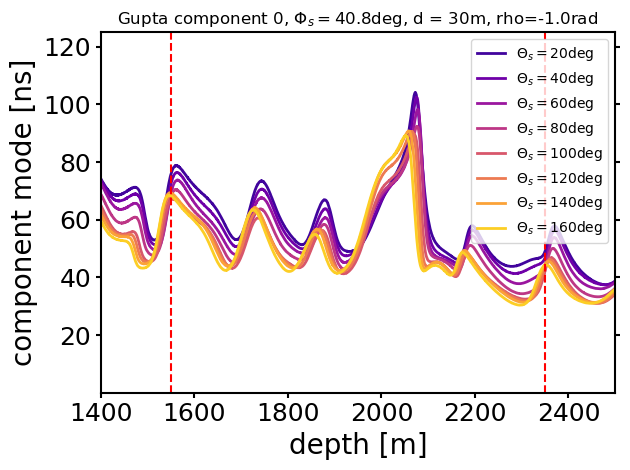

(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)


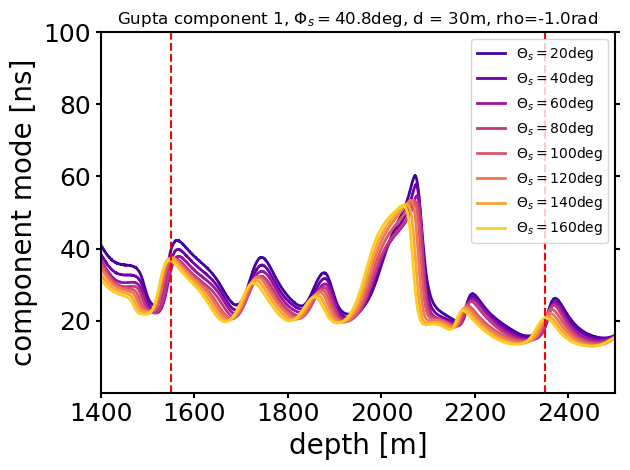

(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)


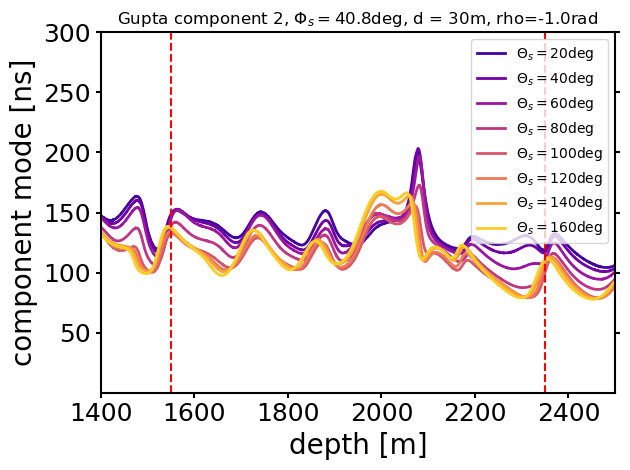

(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)
(10000, 12)


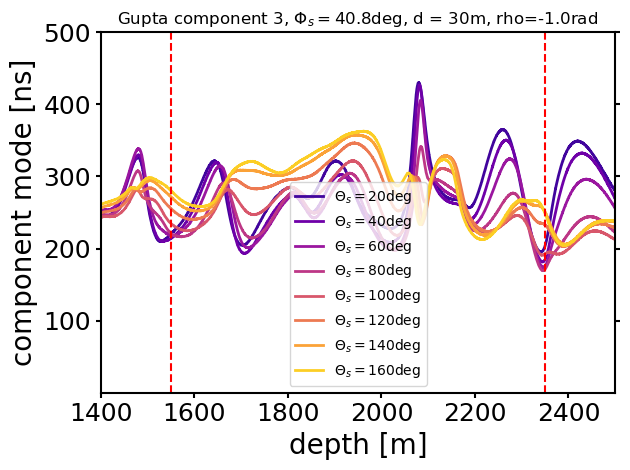

In [30]:
for i in range(4):
    fig, ax = plt.subplots()
    plot_zenith = np.array([j*20 for j in range(1, 9)]).astype(float)
    for j,p_zenith in enumerate(plot_zenith):
        xvals = np.linspace(1400, 2500, 10000).astype(float)

        tmp = []
        for depth in xvals:
            tmp.append([plot_dist2, plot_rho2, 1948.07-depth, np.deg2rad(p_zenith), np.deg2rad(plot_azimuth2)])

        xv = jnp.array(tmp, dtype=jnp.float64)
        y = model_eval(xv)
        print(y.shape)
        # class_probs, gamma_a, gamma_b = y[:, :3], y[:, 3:6], y[:, 6:]
        class_probs, gamma_a, gamma_b = y[:, :4], y[:, 4:8], y[:, 8:]
        class_probs = np.asarray(class_probs)
        gamma_a = np.asarray(gamma_a)
        gamma_b = np.asarray(gamma_b)

        yvals = np.log(gamma_a) / gamma_b

        plt.plot(xvals, yvals[:, i], label=f'$\Theta_s = {p_zenith:.0f}$deg', color=cols[j], lw=2)

    outfile = f"./png/depth_plot_azimuth_gamma_{i}_{plot_azimuth2:.0f}deg_{plot_rho2:.1f}.png"
    plot_args2 = {'xlim':[1400, 2500],
                 'ylim':[1e-3, 1.2 * np.amax(yvals)],
                 'xlabel':'depth [m]',
                 'ylabel':'component mode [ns]'}

    adjust_plot_1d(fig, ax, plot_args=plot_args2)
    if i == 1:
        ax.set_ylim(ymax=100)
    elif i == 0:
        ax.set_ylim(ymax=125)

    elif i == 2:
        ax.set_ylim(ymax=300)

    elif i == 3:
        ax.set_ylim(ymax=500)
    # ax.set_yscale('log')
    ax.axvline(1450+100, color='red', linestyle='dashed')
    ax.axvline(1450+900, color='red', linestyle='dashed')

    plt.title(f"Gupta component {i}, $\Phi_s=${plot_azimuth2:.1f}deg, d = {plot_dist2:.0f}m, rho={plot_rho2}rad")
    plt.tight_layout()
    # plt.savefig(f"newGuptacomponent{i}.png", dpi=300)
    plt.show()
    plt.close()
    # del fig


/tmp/ipykernel_3219349/3761408900.py:17: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  xv = jnp.array(tmp, dtype=jnp.float64)


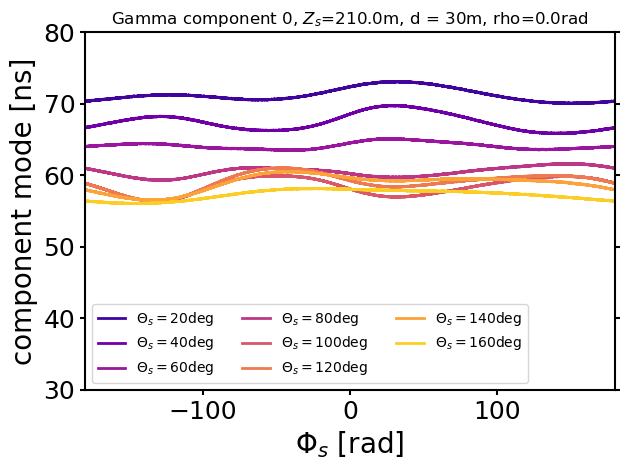

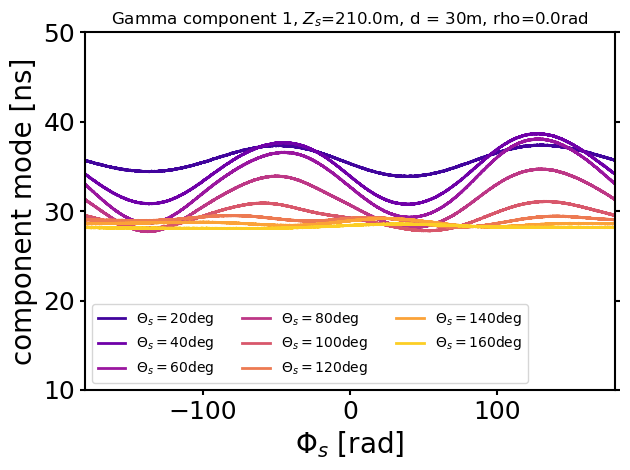

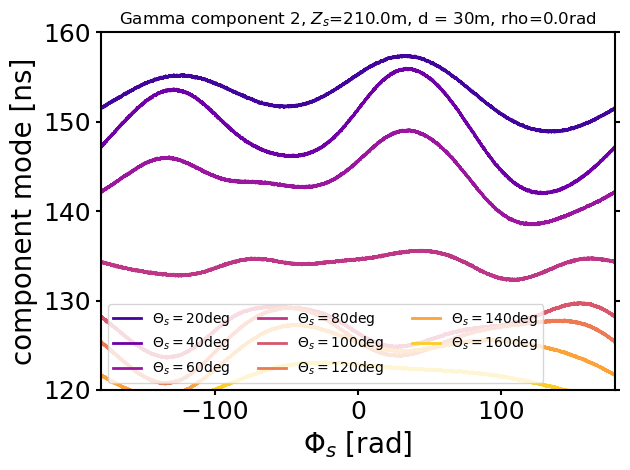

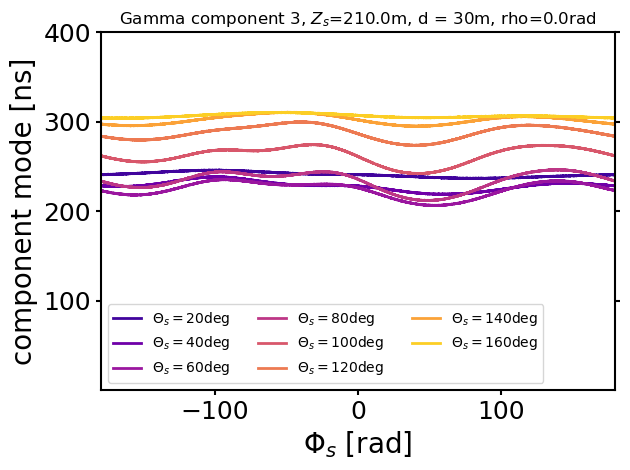

In [34]:
plot_dist = 30
plot_rho = 0.0
plot_z = 210.0

cols = plt.cm.plasma(np.linspace(0.1,0.9, 8))

for i in range(4):
    fig, ax = plt.subplots()
    plot_zenith = [0+i*20 for i in range(1, 9)]
    for j,p_zenith in enumerate(plot_zenith):
        xvals = np.linspace(-180, 180, 10000)

        tmp = []
        for azi in xvals:
            tmp.append([plot_dist, plot_rho, plot_z, np.deg2rad(p_zenith), np.deg2rad(azi)])

        xv = jnp.array(tmp, dtype=jnp.float64)
        y = model_eval(xv)
        class_probs, gamma_a, gamma_b = y[:, :4], y[:, 4:8], y[:, 8:]
        class_probs = np.asarray(class_probs)
        gamma_a = np.asarray(gamma_a)
        gamma_b = np.asarray(gamma_b)

        yvals = np.log(gamma_a) / gamma_b
        idx = yvals < 0
        yvals[idx] = 0

        plt.plot(xvals, yvals[:, i], label=f'$\Theta_s = {p_zenith:.0f}$deg', color=cols[j], lw=2)

    outfile = f"./png/anisotropy_azimuth_gamma_{i}_{plot_z:.0f}m_{plot_dist}_m.png"
    plot_args = {'xlim':[-180, 180],
                 'ylim':[1e-3, 1.2 * np.amax(yvals)],
                 'xlabel':'$\Phi_s$ [rad]',
                 'ylabel':'component mode [ns]'}

    adjust_plot_1d(fig, ax, plot_args=plot_args)
    #ax.set_ylim(ymin=1.e-3)
    if i == 2:
        #ax.set_ylim([15, 30])
        #ax.set_ylim([12, 37])
        ax.set_ylim(120, 160)
    elif i == 0:
        ax.set_ylim([30, 80])

    elif i == 1:
        #ax.set_ylim([10., 30.])
        #ax.set_ylim([20.0, 40.0])
        ax.set_ylim([10.0, 50.0])

    elif i == 3:
        ax.set_ylim(ymax=400)
    ax.legend(ncol=3, loc='lower left')
#
    plt.title(f"Gamma component {i}, $Z_s$={plot_z:.1f}m, d = {plot_dist:.0f}m, rho={plot_rho}rad")
    plt.tight_layout()
    plt.show()